<a href="https://colab.research.google.com/github/Lakshya-13-04/Customer-Churn-Analysis/blob/main/Customer_churn_analysis_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### This is an example code to show the capacity of implementing NN in Production

In [ ]:
!pip install tensorflow

In [ ]:
!pip install keras-tuner

In [ ]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 113.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 5.1 MB/s eta 0:00:00


In [ ]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle
import tensorflow as tf
from tensorflow.keras import layers, models
import keras_tuner as kt #alias
import os
import gradio as gr

In [ ]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Since all columns are not visible therefore we are changing the frame repr and displaying the maximum columns.

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('max_colwidth', None)

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,1,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   int64  
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Droping Some null values
df.dropna(inplace = True)

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Checking For The DUplicated Values
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

### Recursive Feature Elimination

Selected_features by RFE: ['tenure', 'Contract', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


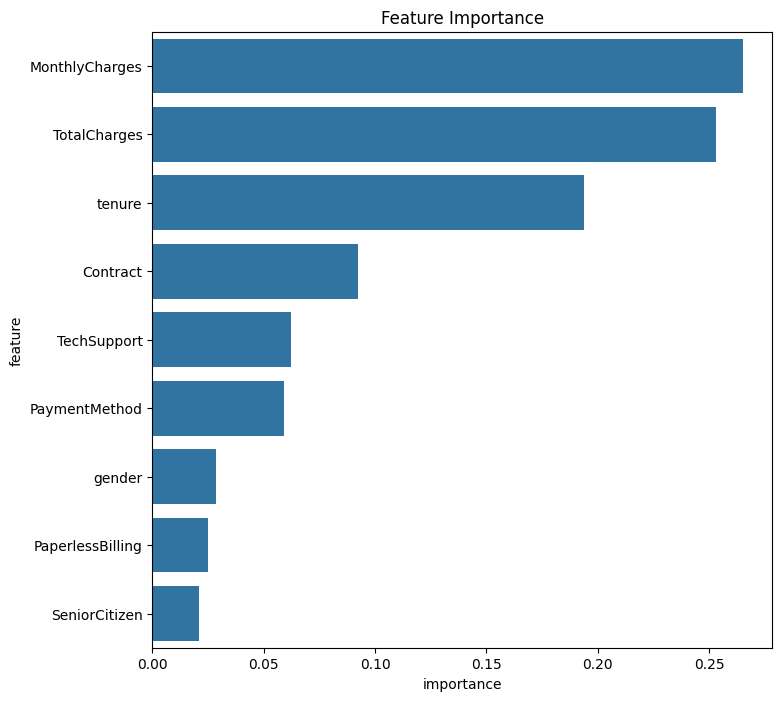

In [ ]:
Numerical_Features = ['gender', 'SeniorCitizen',
       'tenure', 'TechSupport','Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

for col in Numerical_Features:
  if df[col].dtypes == 'object':
    df[col] = pd.factorize(df[col])[0]

Numerical_Features = [f for f in Numerical_Features if f in df.columns]

X = df[Numerical_Features]
y = df['Churn']

rf = RandomForestClassifier(n_estimators= 100, random_state = 42)
rfe = RFE(estimator = rf, n_features_to_select= 5)

rfe.fit(X,y)

selected_features = [feature for feature, selected in zip(Numerical_Features, rfe.support_) if selected]

print(f'Selected_features by RFE: {selected_features}')

rf.fit(X,y)

importances = pd.DataFrame({'feature' : Numerical_Features, 'importance': rf.feature_importances_})
importances = importances.sort_values('importance', ascending = False)
importances

# Ploting Feature vs importance
plt.figure(figsize = (8,8))
sns.barplot(x = 'importance', y = 'feature', data = importances)
plt.title('Feature Importance')
plt.show()

In [ ]:
df[selected_features].head()

,tenure,Contract,PaymentMethod,MonthlyCharges,TotalCharges
0,1,0,0,29.85,29.85
1,34,1,1,56.95,1889.50
2,2,0,1,53.85,108.15
3,45,1,2,42.30,1840.75
4,2,0,0,70.70,151.65


In [ ]:
# Building Our Neural Network
X = df[selected_features]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state= 23)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Saving The file
with open ('scaler.pkl', 'wb') as f:
  pickle.dump(scaler,f)

In [ ]:
#inital model

# def add(a,b):
#   return (f"Sum of {a} and {b} is {a+b}")

# sm = add(2,3)
# print(sm)

def create_model(hp = None):
  if hp:
    model = models.Sequential()

    #first layer. - run
    model.add(layers.Dense(
        units = hp.Choice('units_1', values=[32, 64, 128]),
        activation='relu',
        input_shape=(X_train_scaled.shape[1],),
    ))

    #Optional second layer
    if hp.Boolean('second_layer'):
      model.add(layers.Dense(
          units = hp.Choice("units_2", values=[16,32]),
          activation = 'relu'
      ))

    #output layer (will never change)
    model.add(layers.Dense(1, activation='sigmoid'))

    #compile
    model.compile(
        optimizer = 'adam',
        loss = 'binary_crossentropy',
        metrics = ['accuracy']
    )
  else:
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(8, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
  return model

#build
initial_model = create_model() #empty
initial_model.summary()

history = initial_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.20,   #testing
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7417 - loss: 0.5066 - val_accuracy: 0.7236 - val_loss: 0.4658
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7584 - loss: 0.4551 - val_accuracy: 0.7822 - val_loss: 0.4616
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7933 - loss: 0.4274 - val_accuracy: 0.7893 - val_loss: 0.4659
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7991 - loss: 0.4361 - val_accuracy: 0.7849 - val_loss: 0.4574
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7958 - loss: 0.4314 - val_accuracy: 0.7929 - val_loss: 0.4543
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7924 - loss: 0.4363 - val_accuracy: 0.7840 - val_loss: 0.4568
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7981 - loss: 0.4211 - val_accuracy: 0.7858 - val_loss: 0.4541
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7867 - loss: 0.4215 - val_accuracy: 

In [ ]:
loss, accuracy = initial_model.evaluate(X_test_scaled, y_test)
print(f"Test Loss : {loss}")
print(f"Test Accuracy : {accuracy}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7868 - loss: 0.4348
Test Loss : 0.4434099495410919
Test Accuracy : 0.783226728439331


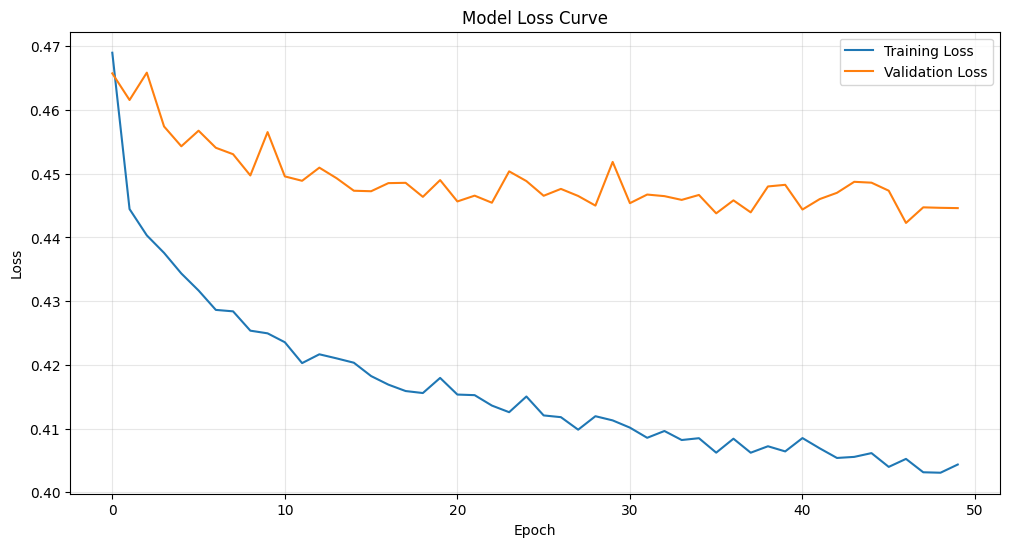

In [ ]:
plt.figure(figsize=(12,6)) #sizing the canvas
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel("Loss")
plt.title("Model Loss Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

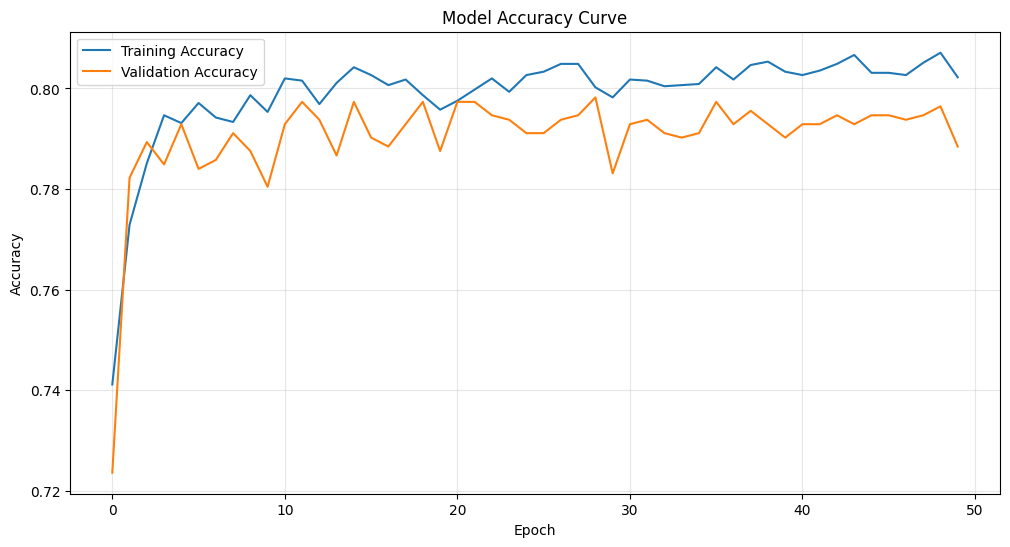

In [ ]:
plt.figure(figsize=(12,6)) #sizing the canvas
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel("Accuracy")
plt.title("Model Accuracy Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
#keras tuner - functiouns depricated


tuner = kt.RandomSearch(
    create_model,
    objective='val_accuracy', #one at a time - two
    max_trials=5,
    directory='keras_tuning',
    project_name='churn_prediction'
)


stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)


tuner.search(
    X_train_scaled, y_train,
    epochs=20,
    validation_split=0.2,
    callbacks=[stop_early],
    verbose=1
)


best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters found:")
for param in best_hps.values:
    print(f"{param}: {best_hps.get(param)}")


best_model = tuner.hypermodel.build(best_hps)
best_history = best_model.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


best_loss, best_accuracy = best_model.evaluate(X_test_scaled, y_test)
print(f"Tuned Model - Test Loss: {best_loss}")
print(f"Tuned Model - Test Accuracy: {best_accuracy}")




Reloading Tuner from keras_tuning/churn_prediction/tuner0.json
Best hyperparameters found:
units_1: 64
second_layer: True
units_2: 32
Epoch 1/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6840 - loss: 0.5734 - val_accuracy: 0.7769 - val_loss: 0.4496
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7812 - loss: 0.4392 - val_accuracy: 0.7804 - val_loss: 0.4470
Epoch 3/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7836 - loss: 0.4424 - val_accuracy: 0.7849 - val_loss: 0.4453
Epoch 4/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7903 - loss: 0.4314 - val_accuracy: 0.7840 - val_loss: 0.4433
Epoch 5/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7896 - loss: 0.4298 - val_accuracy: 0.7867 - val_loss: 0.4417
Epoch 6/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7996 - loss: 0.4144 - val_accuracy: 0.7849 - val_loss: 0.4479
Epoch 7/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7998 - loss: 0.4224 - val_accura

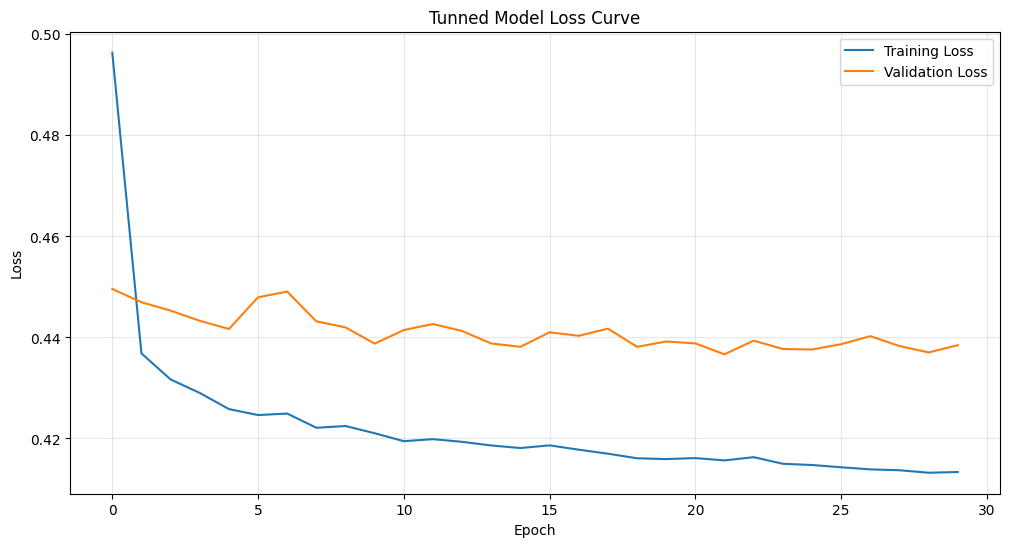

In [ ]:
# Ploting the Graph for monitoring our best model loss
plt.figure(figsize=(12,6))
plt.plot(best_history.history['loss'], label = 'Training Loss')
plt.plot(best_history.history['val_loss'], label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Tunned Model Loss Curve')
plt.grid(alpha = 0.3)
plt.legend()
plt.show()

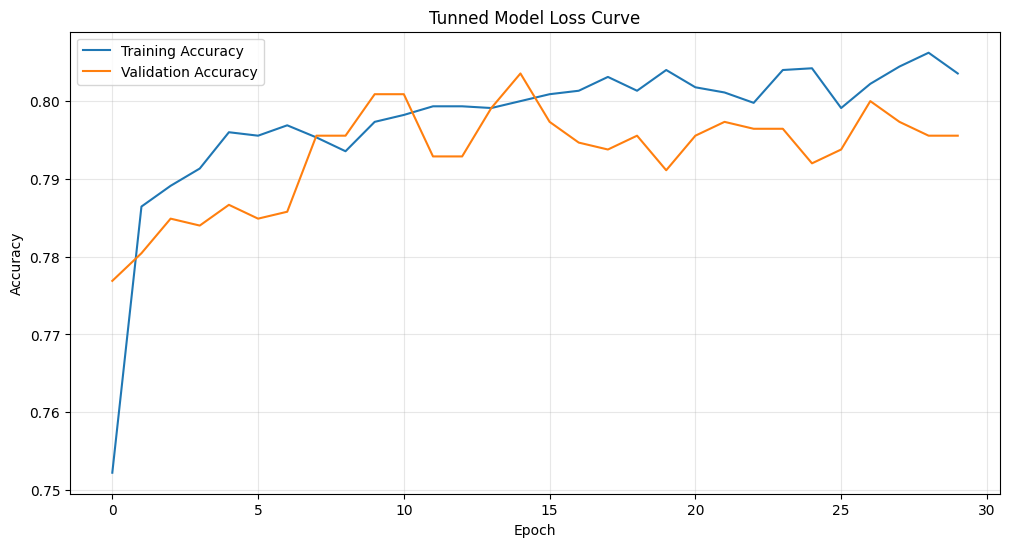

In [ ]:
# Ploting the Graph for monitoring our best model Accuracy
plt.figure(figsize=(12,6))
plt.plot(best_history.history['accuracy'], label = 'Training Accuracy')
plt.plot(best_history.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Tunned Model Loss Curve')
plt.grid(alpha = 0.3)
plt.legend()
plt.show()

In [ ]:
print('Model Comparision')
print(f'Initail Model accuracy: {accuracy: .4f}')
print(f'Tunned Model Accuracy: {best_accuracy: .4f}')
print(f'Imporvement: {(best_accuracy - accuracy)*100: .2f}%')

Model Comparision
Initail Model accuracy:  0.7832
Tunned Model Accuracy:  0.7832
Imporvement:  0.00%


In [ ]:
best_model.save('best_model.h5')

In [ ]:
with open('selected_features.pkl', 'wb') as file:
  pickle.dump(selected_features, file)

In [ ]:
#consume the .h5 model
def load_model_component():
  #load model saved h5 fiormat
  model = tf.keras.models.load_model('best_model.h5') #colab

#read binary. load scaler
  with open('scaler.pkl', 'rb') as file:
    scaler = pickle.load(file)

  #load selcted featires
  with open('selected_features.pkl', 'rb') as file:
    selected_features = pickle.load(file)

  return model, scaler, selected_features

In [ ]:
#Prediction
def predict_churn(*args):
  model, scaler, selected_features = load_model_component()

  input_data = pd.DataFrame([args], columns = selected_features)

  input_scaled = scaler.transform(input_data)

  #making prediction
  prediction = model.predict(input_scaled)[0][0]

  probability = float(prediction)
  churn_status = 'Yes' if probability >0.60 else 'No'

  return {
      'Churn_probability': probability,
      'will churn': churn_status
  }

In [ ]:
def create_gradio_interface():
  model, scaler, selected_features = load_model_component()

  inputs = []

  for feature in selected_features:
    if feature in ['tenure', 'Contract', 'PaymentMethod']:
      inputs.append(gr.Radio(label = feature, choices = [0,1], info = "0 = No/Female, 1 = Yes/Male" ))

    else:
      inputs.append(gr.Slider(minimum=0, maximum= 100 if feature == 'tenure' else 5000, label = feature))

  interface = gr.Interface(
      fn = predict_churn,
      inputs = inputs,
      outputs = gr.JSON(label= 'Churn Prediction'),
      description = 'Churn  prediction NN demo code, kindly use Slider and radio button to feed data',
      examples = [[1,0,1,30,2400]] if len(selected_features) == 5 else None
  )

  return interface

In [ ]:
interface = create_gradio_interface()

In [ ]:
interface.launch()

It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://029115823effa35c36.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
